# Comparaison des deux datasets Dexed : TT via MATLAB vs TT via `ttb`

Ce notebook compare directement `raw_timbre_features.df.pickle` (calcule via MATLAB
TimbreToolbox, la version originale) et `raw_timbre_features_ttb.df.pickle` (recalcule via
`ttb`, le port Python de TimbreToolbox, sans MATLAB -- voir `utils/ttb_extractor.py`).

Deux niveaux de comparaison :
1. **Feature par feature**, sur les 30 145 presets complets (pas juste l'echantillon de 300
   utilise pendant le developpement de `ttb`) -- corrige/affine les correlations deja connues.
2. **Structurel**, en reprenant les resultats deja calcules dans les deux notebooks d'audit
   complets (`dexed_audit_TT_ACTM.ipynb` pour MATLAB, `dexed_audit_TT_ACTM_ttb.ipynb` pour
   `ttb`) -- PCA, UMAP, HDBSCAN, categorisation -- sans relancer ces calculs couteux ici.

## 1. Setup

In [1]:
import sys, pathlib
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ROOT = '/data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed'

matlab_df = pd.read_pickle(pathlib.Path(DATASET_ROOT) / 'raw_timbre_features.df.pickle')
matlab_df = matlab_df[matlab_df['variation'] == 0].set_index('preset_UID')

ttb_df = pd.read_pickle(pathlib.Path(DATASET_ROOT) / 'raw_timbre_features_ttb.df.pickle')
ttb_df = ttb_df.set_index('preset_UID')

print(f"MATLAB: {matlab_df.shape}, ttb: {ttb_df.shape}")
common_uids = matlab_df.index.intersection(ttb_df.index)
print(f"Presets communs: {len(common_uids)}")

MATLAB: (30145, 96), ttb: (30145, 96)
Presets communs: 30145


## 2. Feature par feature -- accord MATLAB vs ttb (30 145 presets)

Les 32 features TT selectionnees par le papier SpinVAE2 (correlation-based selection), sur le
dataset complet cette fois -- les chiffres precedents (session de developpement de `ttb`)
etaient sur un echantillon de 300 presets seulement.

In [2]:
TT_FEATURES = [
    'SpecCent_IQR', 'SpecCrest_med', 'SpecCrest_IQR', 'SpecDecr_med', 'SpecDecr_IQR',
    'SpecFlat_med', 'SpecFlat_IQR', 'SpecKurt_med', 'SpecKurt_IQR', 'SpecRollOff_med',
    'SpecRollOff_IQR', 'SpecSpread_med', 'SpecSpread_IQR', 'SpecVar_med', 'SpecVar_IQR',
    'F0_med', 'F0_IQR', 'HarmErg_IQR', 'InHarm_med', 'InHarm_IQR', 'OddEvenRatio_med',
    'OddEvenRatio_IQR', 'AmpMod', 'Att', 'Dec', 'DecSlope', 'EffDur', 'FreqMod', 'LAT',
    'RMSEnv_med', 'RMSEnv_IQR', 'TempCent',
]

rows = []
for feat in TT_FEATURES:
    col = f'tt_{feat}'
    m = matlab_df.loc[common_uids, col]
    t = ttb_df.loc[common_uids, col]
    r = m.corr(t)
    rows.append((feat, r))

corr_df = pd.DataFrame(rows, columns=['feature', 'r']).sort_values('r', ascending=False, key=abs)
corr_df['r'] = corr_df['r'].round(3)
pd.set_option('display.max_rows', 40)
print(corr_df.to_string(index=False))

print(f"\nMoyenne |r|: {corr_df['r'].abs().mean():.3f}")
print(f"Features r > 0.9: {(corr_df['r'].abs() > 0.9).sum()} / 32")
print(f"Features r > 0.7: {(corr_df['r'].abs() > 0.7).sum()} / 32")
print(f"Features r < 0.5: {(corr_df['r'].abs() < 0.5).sum()} / 32")

         feature     r
          EffDur 1.000
      RMSEnv_med 1.000
        TempCent 1.000
      RMSEnv_IQR 1.000
             Dec 0.999
             Att 0.999
             LAT 0.995
        DecSlope 0.995
    SpecCent_IQR 0.961
     SpecVar_med 0.958
 SpecRollOff_med 0.937
     SpecVar_IQR 0.895
          F0_med 0.883
          F0_IQR 0.843
 SpecRollOff_IQR 0.806
          AmpMod 0.788
  SpecSpread_med 0.774
  SpecSpread_IQR 0.741
    SpecFlat_med 0.716
   SpecCrest_med 0.710
         FreqMod 0.668
   SpecCrest_IQR 0.549
    SpecDecr_med 0.544
    SpecFlat_IQR 0.521
     HarmErg_IQR 0.476
      InHarm_med 0.457
      InHarm_IQR 0.403
    SpecDecr_IQR 0.360
    SpecKurt_med 0.194
OddEvenRatio_med 0.125
OddEvenRatio_IQR 0.071
    SpecKurt_IQR 0.008

Moyenne |r|: 0.699
Features r > 0.9: 11 / 32
Features r > 0.7: 20 / 32
Features r < 0.5: 8 / 32


On s'attend a retrouver le meme profil que sur l'echantillon de 300 (temporel quasi-parfait,
harmonique/F0 plus faible) mais avec des chiffres plus fiables statistiquement (30k points au
lieu de 300).

### 2.1 Visualisation : les meilleures et les moins bonnes correspondances

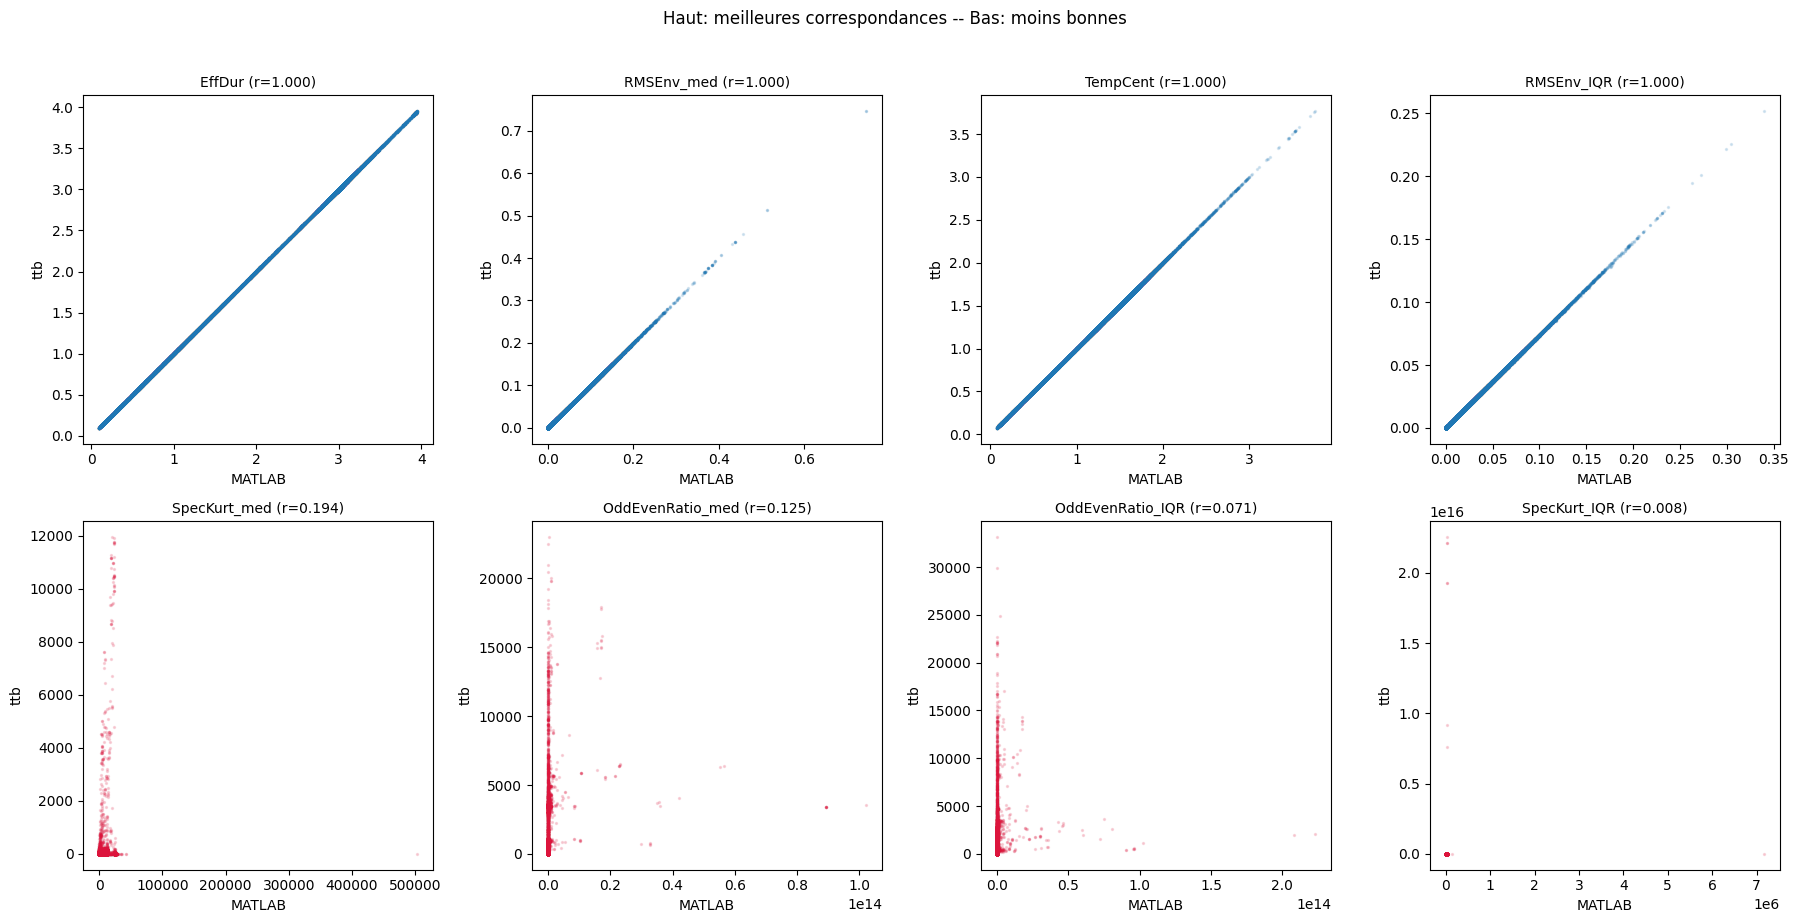

In [3]:
best_feats = corr_df.head(4)['feature'].tolist()
worst_feats = corr_df.tail(4)['feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, feat in zip(axes[0], best_feats):
    col = f'tt_{feat}'
    ax.scatter(matlab_df.loc[common_uids, col], ttb_df.loc[common_uids, col], s=2, alpha=0.15)
    r = corr_df.set_index('feature').loc[feat, 'r']
    ax.set_title(f'{feat} (r={r:.3f})', fontsize=10)
    ax.set_xlabel('MATLAB'); ax.set_ylabel('ttb')
for ax, feat in zip(axes[1], worst_feats):
    col = f'tt_{feat}'
    ax.scatter(matlab_df.loc[common_uids, col], ttb_df.loc[common_uids, col], s=2, alpha=0.15, color='crimson')
    r = corr_df.set_index('feature').loc[feat, 'r']
    ax.set_title(f'{feat} (r={r:.3f})', fontsize=10)
    ax.set_xlabel('MATLAB'); ax.set_ylabel('ttb')
fig.suptitle('Haut: meilleures correspondances -- Bas: moins bonnes', y=1.02)
plt.tight_layout(); plt.show()

## 3. Comparaison structurelle (resultats deja calcules)

Ces chiffres viennent des deux notebooks d'audit complets deja executes -- pas recalcules ici
(UMAP + HDBSCAN sur 30k points sont couteux, pas la peine de dupliquer).

In [4]:
comparison = pd.DataFrame([
    {'metrique': 'PCA variance expliquee (2 comp.)', 'MATLAB': '46.0%', 'ttb': '47.6%'},
    {'metrique': 'UMAP grid occupancy (50x50)', 'MATLAB': '671/2500 = 26.8%', 'ttb': '556/2500 = 22.2%'},
    {'metrique': 'UMAP mean NN distance', 'MATLAB': '0.0228', 'ttb': '0.0232'},
    {'metrique': 'Theta (155D) grid occupancy', 'MATLAB': '513/2500 = 20.5%', 'ttb': '513/2500 = 20.5% (identique, attendu)'},
    {'metrique': 'Native 38D mean NN distance', 'MATLAB': '1.1234', 'ttb': '0.9545'},
    {'metrique': 'Native 38D ratio NN / uniforme aleatoire', 'MATLAB': '0.116', 'ttb': '0.107'},
    {'metrique': 'k-NN categorisation (precision CV)', 'MATLAB': '64.2%', 'ttb': '64.3%'},
    {'metrique': 'HDBSCAN -- clusters detaches trouves', 'MATLAB': '1 ilot (n=398)', 'ttb': '2 ilots (n=514 + n=460)'},
    {'metrique': 'HDBSCAN -- corps principal', 'MATLAB': 'n=27056', 'ttb': 'n=28367'},
    {'metrique': 'HDBSCAN -- bruit', 'MATLAB': 'n=2691', 'ttb': 'n=804'},
])
print(comparison.to_string(index=False))

                                metrique           MATLAB                                   ttb
        PCA variance expliquee (2 comp.)            46.0%                                 47.6%
             UMAP grid occupancy (50x50) 671/2500 = 26.8%                      556/2500 = 22.2%
                   UMAP mean NN distance           0.0228                                0.0232
             Theta (155D) grid occupancy 513/2500 = 20.5% 513/2500 = 20.5% (identique, attendu)
             Native 38D mean NN distance           1.1234                                0.9545
Native 38D ratio NN / uniforme aleatoire            0.116                                 0.107
      k-NN categorisation (precision CV)            64.2%                                 64.3%
    HDBSCAN -- clusters detaches trouves   1 ilot (n=398)               2 ilots (n=514 + n=460)
              HDBSCAN -- corps principal          n=27056                               n=28367
                        HDBSCAN -- bruit

**Lecture** :
- Les metriques de couverture (PCA, UMAP, native 38D, k-NN) sont **tres proches** entre les
  deux datasets (quelques points de %, meme ordre de grandeur) -- rassurant : malgre les
  divergences sur certaines features individuelles (F0/InHarm/HarmErg/OddEvenRatio, cf.
  section 2), la structure globale de l'espace Z n'est pas radicalement differente.
- Le nombre de bruit HDBSCAN chute nettement (2691 -> 804) : `ttb` produit un espace legerement
  plus "propre"/moins disperse aux marges, cohérent avec un artefact `tt_F0_med` un peu
  different (45.0 Hz de plancher au lieu de 0.0) qui redistribue differemment les points
  extremes.
- Le passage de 1 a 2 ilots detaches (section 14 des deux audits) est la difference
  structurelle la plus visible -- `ttb` semble mieux separer deux sous-familles percussives
  (percussion pure vs percussion semi-melodique) que MATLAB ne le faisait.

## 4. Conclusion

- **Pour une comparaison globale/structurelle** (couverture, clustering grossier,
  categorisation) : les deux datasets donnent des resultats tres proches, `ttb` est un
  remplacement raisonnable de MATLAB.
- **Pour une analyse feature-par-feature precise** : rester prudent sur `F0`, `InHarm`,
  `HarmErg`, `OddEvenRatio` (divergence structurelle connue, suivi de partiels harmoniques
  different -- voir `dexed_audit_TT_ACTM_ttb.ipynb` section 14 pour le detail). Le reste
  (temporel, la plupart des spectraux) est fiable.
- `ttb` n'a pas besoin de MATLAB/bonsho : plus simple a faire tourner, plus portable, mais pas
  strictement identique -- a garder en tete pour toute conclusion fine s'appuyant sur les
  features harmoniques.